In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

In [2]:
taxi_data = pd.read_csv('Taxi_Trip_Data.csv')

C:\Users\91767\AppData\Local\Temp\ipykernel_13108\4211305913.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  taxi_data = pd.read_csv('Taxi_Trip_Data.csv')


In [3]:
taxi_data

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,01/01/2020 12:28:15 AM,01/01/2020 12:33:03 AM,1.0,1.20,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,01/01/2020 12:35:39 AM,01/01/2020 12:43:04 AM,1.0,1.20,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,01/01/2020 12:47:41 AM,01/01/2020 12:53:52 AM,1.0,0.60,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,01/01/2020 12:55:23 AM,01/01/2020 01:00:14 AM,1.0,0.80,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,01/01/2020 12:01:58 AM,01/01/2020 12:04:16 AM,1.0,0.00,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,2.0,02/01/2020 12:52:43 PM,02/01/2020 01:02:11 PM,1.0,1.21,1.0,N,238,239,1.0,7.5,0.0,0.5,2.16,0.00,0.3,14.91,2.5
6499996,2.0,02/01/2020 12:38:19 PM,02/01/2020 01:19:03 PM,1.0,17.77,2.0,N,132,100,1.0,52.0,0.0,0.5,12.28,6.12,0.3,73.70,2.5
6499997,2.0,02/01/2020 12:12:39 PM,02/01/2020 12:25:20 PM,1.0,3.57,1.0,N,13,33,1.0,13.5,0.0,0.5,3.36,0.00,0.3,20.16,2.5
6499998,2.0,02/01/2020 12:42:47 PM,02/01/2020 01:09:27 PM,1.0,5.85,1.0,N,209,230,2.0,23.5,0.0,0.5,0.00,0.00,0.3,26.80,2.5


In [4]:
taxi_df = taxi_data.dropna(subset=['VendorID'])
taxi_data.isnull().sum()

VendorID                 79229
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          79229
trip_distance                0
RatecodeID               79229
store_and_fwd_flag       79229
PULocationID                 0
DOLocationID                 0
payment_type             79229
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
dtype: int64

In [5]:
taxi_df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
dtype: int64

In [11]:
taxi_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,01/01/2020 12:28:15 AM,01/01/2020 12:33:03 AM,1.0,1.20,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,01/01/2020 12:35:39 AM,01/01/2020 12:43:04 AM,1.0,1.20,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,01/01/2020 12:47:41 AM,01/01/2020 12:53:52 AM,1.0,0.60,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,01/01/2020 12:55:23 AM,01/01/2020 01:00:14 AM,1.0,0.80,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,01/01/2020 12:01:58 AM,01/01/2020 12:04:16 AM,1.0,0.00,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,2.0,02/01/2020 12:52:43 PM,02/01/2020 01:02:11 PM,1.0,1.21,1.0,N,238,239,1.0,7.5,0.0,0.5,2.16,0.00,0.3,14.91,2.5
6499996,2.0,02/01/2020 12:38:19 PM,02/01/2020 01:19:03 PM,1.0,17.77,2.0,N,132,100,1.0,52.0,0.0,0.5,12.28,6.12,0.3,73.70,2.5
6499997,2.0,02/01/2020 12:12:39 PM,02/01/2020 12:25:20 PM,1.0,3.57,1.0,N,13,33,1.0,13.5,0.0,0.5,3.36,0.00,0.3,20.16,2.5
6499998,2.0,02/01/2020 12:42:47 PM,02/01/2020 01:09:27 PM,1.0,5.85,1.0,N,209,230,2.0,23.5,0.0,0.5,0.00,0.00,0.3,26.80,2.5


In [6]:
def infer_sql_types(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'TIMESTAMP'
    else:
        return 'TEXT'
table_name = 'Taxi_Trip_Data'
columns = taxi_data.dtypes
sql_columns = ',\n '.join([f'"{col}"{infer_sql_types(dtype)}' for col, dtype in columns.items()])

create_stmt = f"""
CREATE TABLE IF NOT EXISTS {table_name} (
 {sql_columns}
);
"""

print(create_stmt)


CREATE TABLE IF NOT EXISTS Taxi_Trip_Data (
 "VendorID"FLOAT,
 "tpep_pickup_datetime"TEXT,
 "tpep_dropoff_datetime"TEXT,
 "passenger_count"FLOAT,
 "trip_distance"FLOAT,
 "RatecodeID"FLOAT,
 "store_and_fwd_flag"TEXT,
 "PULocationID"INT,
 "DOLocationID"INT,
 "payment_type"FLOAT,
 "fare_amount"FLOAT,
 "extra"FLOAT,
 "mta_tax"FLOAT,
 "tip_amount"FLOAT,
 "tolls_amount"FLOAT,
 "improvement_surcharge"FLOAT,
 "total_amount"FLOAT,
 "congestion_surcharge"FLOAT
);



In [7]:
import psycopg2
conn = psycopg2.connect(
    dbname = "postgres",
    user="postgres",
    password="postgres",
    host="localhost",
    port="5432"
)

cur = conn.cursor()
# Create table manually here or auto-generate
cur.execute(create_stmt)
conn.commit()

# Auto-generate INSERT statement
columns = list(taxi_data.columns)
placeholders = ', '.join(['%s'] * len(columns))
insert_stmt = f"""INSERT INTO {table_name} ({', '.join(['"{}"'.format(col) for col in columns])}) 
VALUES ({placeholders})
"""

# Insert data row by row
for _, row in taxi_data.iterrows():
    cur.execute(insert_stmt, tuple(row))


conn.commit()
cur.close()
conn.close()


In [ ]:
taxi_df['pickup_datetime'] = pd.to_datetime(taxi_df['tpep_pickup_datetime'])

C:\Users\91767\AppData\Local\Temp\ipykernel_6640\1615624708.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  taxi_df['pickup_datetime'] = pd.to_datetime(taxi_df['tpep_pickup_datetime'])


In [ ]:
taxi_df['pickup_datetime']

In [5]:
taxi_df.groupby(['PULocationID','DOLocationID']).size()

PULocationID  DOLocationID
1             1                644
              50                 1
              68                 1
              138                2
              140                1
                              ... 
265           259                1
              261                1
              263                4
              264              327
              265             2535
Length: 26564, dtype: int64

In [6]:
taxi_df['total_amount'].sum()

118490151.53999993

In [8]:
correlation = taxi_df['trip_distance'].corr(taxi_df['fare_amount'])
correlation

0.8467746235928094

In [12]:
fraud_trips = taxi_df[(taxi_df['fare_amount'] > 30) & (taxi_df['trip_distance'] < 1)]
fraud_trips.shape[0]

34738

In [15]:
trips_top5 = taxi_df.sort_values(by='total_amount', ascending=False).head(5)[['total_amount','trip_distance']]
trips_top5

,total_amount,trip_distance
4058475,4268.30,1.57
5070306,1722.30,58.85
472265,1242.30,8.27
4277560,1110.80,0.55
1026422,1040.39,0.00


In [19]:
#Which drop-off location generated the highest total fare revenue?
taxi_df.sort_values(by='fare_amount',ascending=False ).head(1)[['DOLocationID','fare_amount']]

,DOLocationID,fare_amount
4058475,152,4265.0


In [11]:
class taxi_data_analysis:
    def __init__(self,taxi_df):
        taxi_df.self = self
    def least_fare_amount(self):
        return taxi_df.sort_values (by  = 'fare_amount',ascending = True)[['fare_amount','trip_distance']].head(1).reset_index()
    def avg_trip_distance(self):
        return taxi_df['trip_distance'].mean()
    def no_of_trip_per_payment_type(self):
        return taxi_df.groupby('payment_type').size()
    def overloaded_passengers(self):
        return taxi_df[taxi_df['passenger_count']>4].shape[0]
    def overall_amount(self):
        return taxi_df['total_amount'].sum()
    def correlation(self):
        correlation = taxi_df['trip_distance'].corr(taxi_df['fare_amount'])
        return correlation
    def fraud_trips(self):
        fraud_trips = taxi_df[(taxi_df['fare_amount'] > 30) & (taxi_df['trip_distance'] < 1)]
        return fraud_trips.shape[0]
    def top5_trips(self):
        trips_top5 = taxi_df.sort_values(by='total_amount', ascending=False).head(5)[['total_amount','trip_distance']]
        return trips_top5
    def drop_loc_highest_fare(self):
        return taxi_df.sort_values(by='fare_amount',ascending=False ).head(1)[['DOLocationID','fare_amount']]
    def pie_chart(self):
        payment_counts = taxi_df['payment_type'].value_counts()
        plt.figure(figsize=(6, 6))
        plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
        plt.title('Percentage Share of Payment Types')
        plt.show()
        return payment_counts
    def passenger_count(self):
        return taxi_df.groupby('passenger_count').size()
    def highest_passenger_travelled(self):
        return taxi_df.groupby('passenger_count').size().sort_values(ascending=False).head(1)

In [12]:
obj_balu = taxi_data_analysis(taxi_df)

print('least fare amount:')
print(obj_balu.least_fare_amount())

print('avg_trip_distance:')
print(obj_balu.avg_trip_distance())

print('no. of trips per each payment type:')
print(obj_balu.no_of_trip_per_payment_type())

print('more than 4 passengers trip counts:')
print(obj_balu.overloaded_passengers())

print('overall amount collected:')
print(obj_balu.overall_amount())

print('correlation btw trip & fare amount:')
print(obj_balu.correlation())

print('fraud_trips_detection:')
print(obj_balu.fraud_trips())

print('top5 trips:')
print(obj_balu.top5_trips())

print('drop location highest fare amount:')
print(obj_balu.drop_loc_highest_fare())

print('passengers_count:')
print(obj_balu.passenger_count())

print('Highest passenger travelled in a trip:')
print(obj_balu.highest_passenger_travelled())

least fare amount:
    index  fare_amount  trip_distance
0  472264      -1238.0           8.27
avg_trip_distance:
2.8477062147209407
no. of trips per each payment type:
payment_type
1.0    4754867
2.0    1614300
3.0      33216
4.0      18387
5.0          1
dtype: int64
more than 4 passengers trip counts:
362827
overall amount collected:
118490151.53999993
correlation btw trip & fare amount:
0.8467746235928094
fraud_trips_detection:
34738
top5 trips:
         total_amount  trip_distance
4058475       4268.30           1.57
5070306       1722.30          58.85
472265        1242.30           8.27
4277560       1110.80           0.55
1026422       1040.39           0.00
drop location highest fare amount:
         DOLocationID  fare_amount
4058475           152       4265.0
passengers_count:
passenger_count
0.0     115771
1.0    4604359
2.0     959137
3.0     253553
4.0     125124
5.0     228784
6.0     133978
7.0         29
8.0         17
9.0         19
dtype: int64
Highest passenger trav

In [11]:
# STATISTICAL ANALYSIS
#CORRELATION
con_cols = taxi_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
con_cols

['VendorID',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge']

In [3]:
cat_cols = [col for col in taxi_data.columns if taxi_data[col].dtypes == 'object']
cat_cols

['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag']

pie_chart:


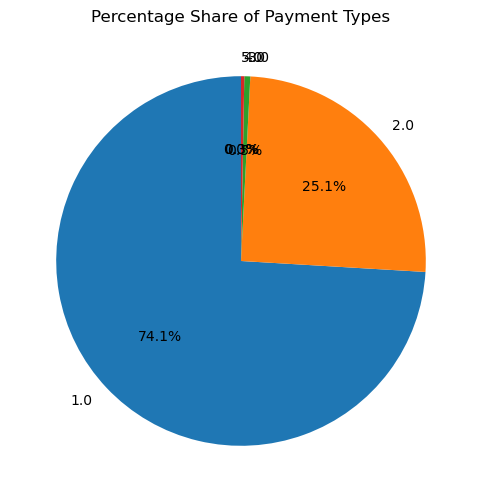

payment_type
1.0    4754867
2.0    1614300
3.0      33216
4.0      18387
5.0          1
Name: count, dtype: int64


In [51]:
print('pie_chart:')
print(obj_balu.pie_chart())

<Axes: xlabel='store_and_fwd_flag', ylabel='Count'>

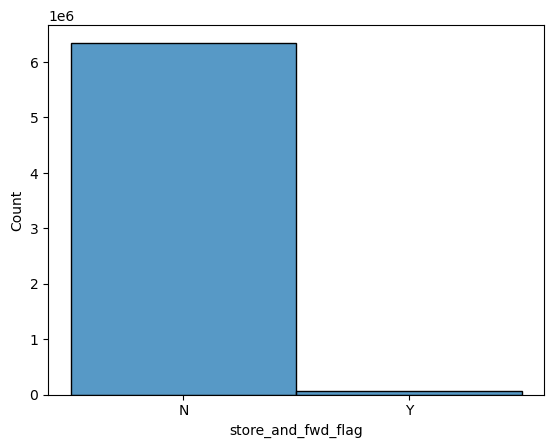

In [69]:
sns.histplot(taxi_df['store_and_fwd_flag'])

Text(0.5, 1.0, 'Box plot of tip amount')

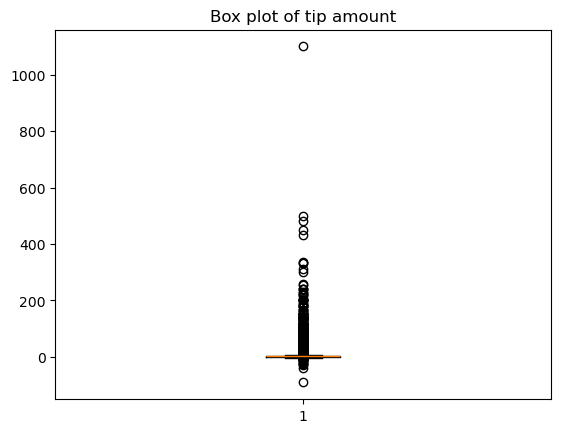

In [79]:
plt.boxplot(taxi_df['tip_amount'])
plt.title('Box plot of tip amount')

Text(0.5, 1.0, 'Scatterplot of total amount vs fare amount')

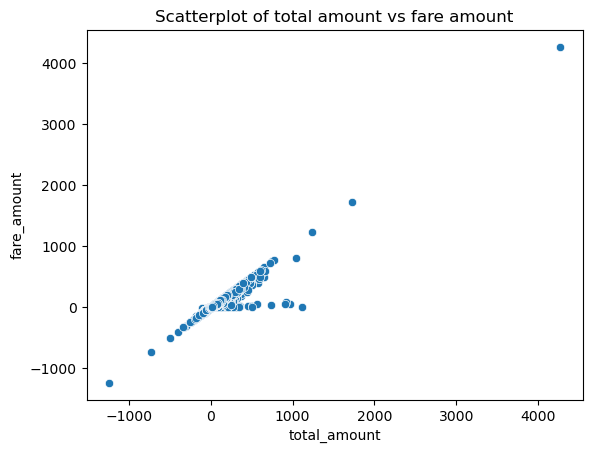

In [81]:
sns.scatterplot(data = taxi_df,x = 'total_amount',y = 'fare_amount')
plt.title('Scatterplot of total amount vs fare amount')

<Axes: >

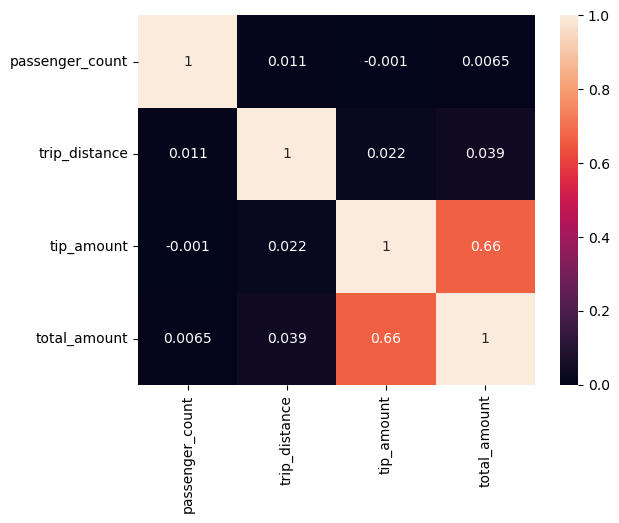

In [6]:
sns.heatmap(taxi_data[['passenger_count','trip_distance','tip_amount','total_amount']].corr(),annot = True)

In [5]:
def get_outliers(col):
    q1 = taxi_data[col].describe()['25%']
    q3 = taxi_data[col].describe()['75%']
    iqr = q3-q1
    return [val for val in taxi_data['total_amount'].values if val >q3 + (1.5*iqr)],\
           [val for val in taxi_data['total_amount'].values if val<q1-(1.5*iqr)]

get_outliers('total_amount')

([37.14,
  35.15,
  35.15,
  52.71,
  50.76,
  100.3,
  36.3,
  44.76,
  37.7,
  45.36,
  34.67,
  48.5,
  33.12,
  60.52,
  32.8,
  73.7,
  61.7,
  40.42,
  58.92,
  35.16,
  50.3,
  34.3,
  34.75,
  37.56,
  56.16,
  35.75,
  33.35,
  32.88,
  36.96,
  62.66,
  62.16,
  51.95,
  56.3,
  65.3,
  69.12,
  75.36,
  40.8,
  41.8,
  36.42,
  33.96,
  57.47,
  39.39,
  36.3,
  36.63,
  49.67,
  44.76,
  36.14,
  37.8,
  38.3,
  40.0,
  79.82,
  34.1,
  37.56,
  70.02,
  55.3,
  73.67,
  70.3,
  33.8,
  32.89,
  38.3,
  46.56,
  39.8,
  36.96,
  46.3,
  157.8,
  44.3,
  42.25,
  34.75,
  36.62,
  36.36,
  35.49,
  34.56,
  36.95,
  44.1,
  35.15,
  45.8,
  33.88,
  41.75,
  34.56,
  43.3,
  38.1,
  33.35,
  33.54,
  50.8,
  34.56,
  37.1,
  40.7,
  34.8,
  37.88,
  63.18,
  66.3,
  41.92,
  50.42,
  33.12,
  47.25,
  35.49,
  46.3,
  55.8,
  38.16,
  69.1,
  51.96,
  110.42,
  33.36,
  40.6,
  47.49,
  33.36,
  33.96,
  33.36,
  73.67,
  51.92,
  38.76,
  34.1,
  52.7,
  38.76,
  41.0,
  42